In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
#Load gene-level pearson correlation metrics

n_targets = 100
n_reps = 4

rp_prime = np.zeros((n_targets, n_reps))
rp_borzoi = np.zeros((n_targets, n_reps))

rp_prime_norm = np.zeros((n_targets, n_reps))
rp_borzoi_norm = np.zeros((n_targets, n_reps))

rp_prime_gene = np.zeros((n_targets, n_reps))
rp_borzoi_gene = np.zeros((n_targets, n_reps))

#Loop over reps and record metrics
for rep_ix in range(n_reps) :
    prime_df = pd.read_csv('/home/jlinder/borzoi_sc/borzoi/examples/saved_models_mouse_brain/f3c' + str(rep_ix) + '/testg_32/acc.txt', index_col=0, sep='\t')
    borzoi_df = pd.read_csv('/home/jlinder/borzoi/examples/saved_models_mouse_brain/f3c' + str(rep_ix) + '/testg/acc.txt', index_col=0, sep='\t')
    
    rp_prime[:, rep_ix] = prime_df['pearsonr'].values
    rp_borzoi[:, rep_ix] = borzoi_df['pearsonr'].values
    rp_prime_norm[:, rep_ix] = prime_df['pearsonr_norm'].values
    rp_borzoi_norm[:, rep_ix] = borzoi_df['pearsonr_norm'].values
    rp_prime_gene[:, rep_ix] = prime_df['pearsonr_gene'].values
    rp_borzoi_gene[:, rep_ix] = borzoi_df['pearsonr_gene'].values

#Filter NaNs
keep_index = np.nonzero(~(np.any(np.isnan(rp_prime_gene), axis=1) | np.any(np.isnan(rp_borzoi_gene), axis=1)))[0]

rp_prime = rp_prime[keep_index, :]
rp_borzoi = rp_borzoi[keep_index, :]
rp_prime_norm = rp_prime_norm[keep_index, :]
rp_borzoi_norm = rp_borzoi_norm[keep_index, :]
rp_prime_gene = rp_prime_gene[keep_index, :]
rp_borzoi_gene = rp_borzoi_gene[keep_index, :]

print("rp_prime.shape = " + str(rp_prime.shape))
print("rp_borzoi.shape = " + str(rp_borzoi.shape))
print("")
print("rp_prime_norm.shape = " + str(rp_prime_norm.shape))
print("rp_borzoi_norm.shape = " + str(rp_borzoi_norm.shape))
print("")
print("rp_prime_gene.shape = " + str(rp_prime_gene.shape))
print("rp_borzoi_gene.shape = " + str(rp_borzoi_gene.shape))


rp_prime.shape = (90, 4)
rp_borzoi.shape = (90, 4)

rp_prime_norm.shape = (90, 4)
rp_borzoi_norm.shape = (90, 4)

rp_prime_gene.shape = (90, 4)
rp_borzoi_gene.shape = (90, 4)


(gene-level)
pearson r (prime) = 0.8909
pearson r (borzoi) = 0.8886


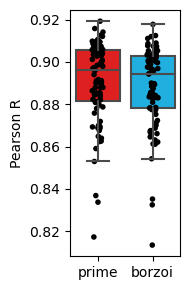

(gene-level norm)
pearson r (prime) = 0.2499
pearson r (borzoi) = 0.2233


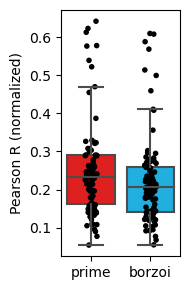

(within-gene)
pearson r (prime) = 0.8056
pearson r (borzoi) = 0.7424


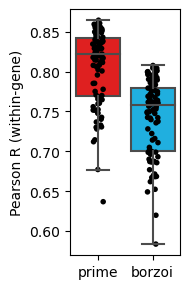

In [7]:
#Compare average performance between borzoi and borzoi prime

print("(gene-level)")
print("pearson r (prime) = " + str(round(np.mean(rp_prime), 4)))
print("pearson r (borzoi) = " + str(round(np.mean(rp_borzoi), 4)))

#Gene-level
f = plt.figure(figsize=(2, 3))

sns.boxplot(data=[np.mean(rp_prime, axis=-1), np.mean(rp_borzoi, axis=-1)], palette=['red', 'deepskyblue'], fliersize=0)
sns.stripplot(data=[np.mean(rp_prime, axis=-1), np.mean(rp_borzoi, axis=-1)], palette=['black', 'black'], s=4, zorder=1)

plt.xticks([0, 1], ['prime', 'borzoi'], fontsize=10)
plt.yticks(fontsize=10)

plt.ylabel('Pearson R', fontsize=10)

plt.tight_layout()

plt.savefig('mouse_brain_testg_pearsonr.eps')

plt.show()

print("(gene-level norm)")
print("pearson r (prime) = " + str(round(np.mean(rp_prime_norm), 4)))
print("pearson r (borzoi) = " + str(round(np.mean(rp_borzoi_norm), 4)))

#Gene-level (norm)
f = plt.figure(figsize=(2, 3))

sns.boxplot(data=[np.mean(rp_prime_norm, axis=-1), np.mean(rp_borzoi_norm, axis=-1)], palette=['red', 'deepskyblue'], fliersize=0)
sns.stripplot(data=[np.mean(rp_prime_norm, axis=-1), np.mean(rp_borzoi_norm, axis=-1)], palette=['black', 'black'], s=4, zorder=1)

plt.xticks([0, 1], ['prime', 'borzoi'], fontsize=10)
plt.yticks(fontsize=10)

plt.ylabel('Pearson R (normalized)', fontsize=10)

plt.tight_layout()

plt.savefig('mouse_brain_testg_pearsonr_norm.eps')

plt.show()

print("(within-gene)")
print("pearson r (prime) = " + str(round(np.mean(rp_prime_gene), 4)))
print("pearson r (borzoi) = " + str(round(np.mean(rp_borzoi_gene), 4)))

#Within-gene
f = plt.figure(figsize=(2, 3))

sns.boxplot(data=[np.mean(rp_prime_gene, axis=-1), np.mean(rp_borzoi_gene, axis=-1)], palette=['red', 'deepskyblue'], fliersize=0)
sns.stripplot(data=[np.mean(rp_prime_gene, axis=-1), np.mean(rp_borzoi_gene, axis=-1)], palette=['black', 'black'], s=4, zorder=1)

plt.xticks([0, 1], ['prime', 'borzoi'], fontsize=10)
plt.yticks(fontsize=10)

plt.ylabel('Pearson R (within-gene)', fontsize=10)

plt.tight_layout()

plt.savefig('mouse_brain_testg_pearsonr_gene.eps')

plt.show()
